Using device: cuda
Class mapping: {'fake': 0, 'real': 1}

===== ResNet18 RGB - JPEG50 RESULT =====
Test Unseen Loss: 1.6972
Test Unseen Acc:  0.4147
Test Unseen AUC:  0.9985

Confusion Matrix
[[122 878]
 [  0 500]]
              precision    recall  f1-score   support

           0       1.00      0.12      0.22      1000
           1       0.36      1.00      0.53       500

    accuracy                           0.41      1500
   macro avg       0.68      0.56      0.37      1500
weighted avg       0.79      0.41      0.32      1500



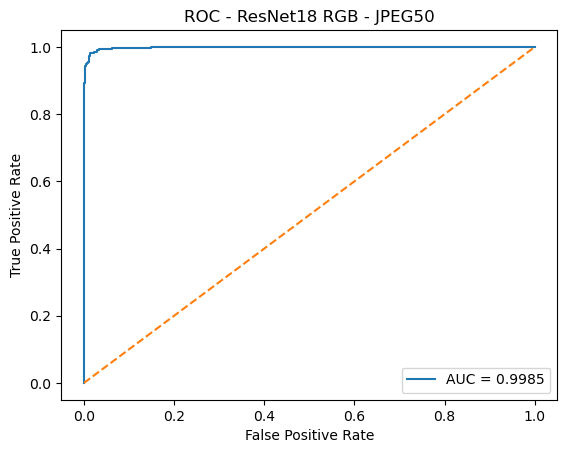


===== MobileNetV2 RGB - JPEG50 RESULT =====
Test Unseen Loss: 2.5069
Test Unseen Acc:  0.3827
Test Unseen AUC:  0.9967

Confusion Matrix
[[ 74 926]
 [  0 500]]
              precision    recall  f1-score   support

           0       1.00      0.07      0.14      1000
           1       0.35      1.00      0.52       500

    accuracy                           0.38      1500
   macro avg       0.68      0.54      0.33      1500
weighted avg       0.78      0.38      0.26      1500



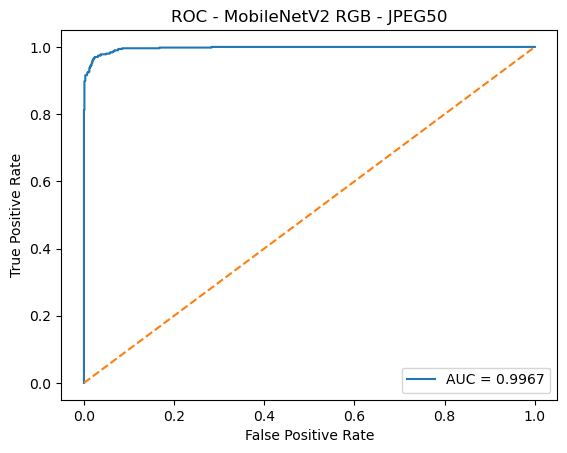


===== EfficientNet-B0 RGB - JPEG50 RESULT =====
Test Unseen Loss: 2.7425
Test Unseen Acc:  0.3640
Test Unseen AUC:  0.9856

Confusion Matrix
[[ 46 954]
 [  0 500]]
              precision    recall  f1-score   support

           0       1.00      0.05      0.09      1000
           1       0.34      1.00      0.51       500

    accuracy                           0.36      1500
   macro avg       0.67      0.52      0.30      1500
weighted avg       0.78      0.36      0.23      1500



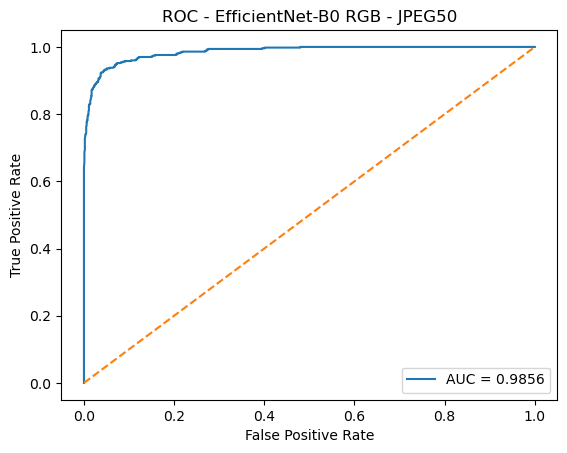


===== ViT-B/16 RGB - JPEG50 RESULT =====
Test Unseen Loss: 0.3989
Test Unseen Acc:  0.8927
Test Unseen AUC:  0.9961

Confusion Matrix
[[840 160]
 [  1 499]]
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      1000
           1       0.76      1.00      0.86       500

    accuracy                           0.89      1500
   macro avg       0.88      0.92      0.89      1500
weighted avg       0.92      0.89      0.90      1500



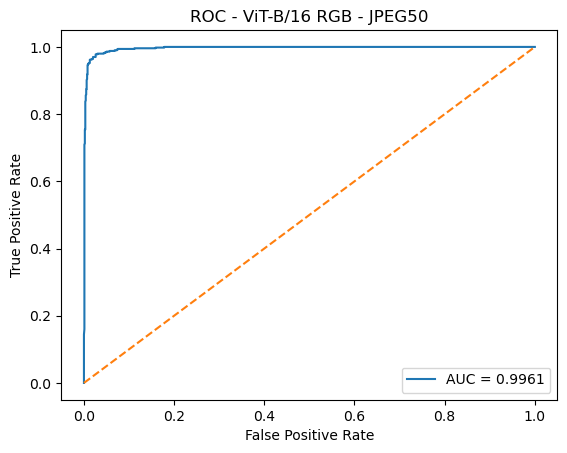


===== DMFNet RGB - JPEG50 RESULT =====
Test Unseen Loss: 0.3215
Test Unseen Acc:  0.8753
Test Unseen AUC:  0.9996

Confusion Matrix
[[813 187]
 [  0 500]]
              precision    recall  f1-score   support

           0       1.00      0.81      0.90      1000
           1       0.73      1.00      0.84       500

    accuracy                           0.88      1500
   macro avg       0.86      0.91      0.87      1500
weighted avg       0.91      0.88      0.88      1500



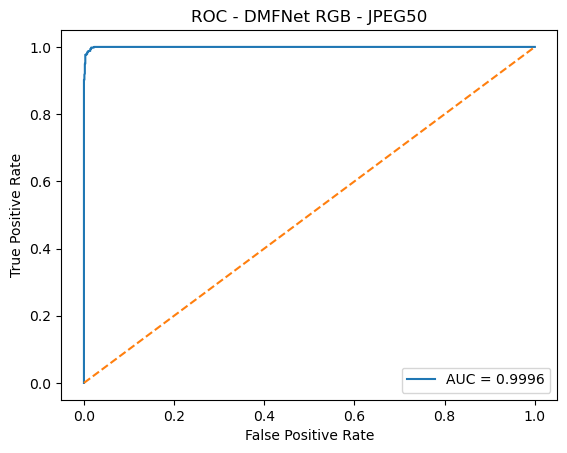


===== Hybrid RGB - JPEG50 RESULT =====
Test Unseen Loss: 3.7353
Test Unseen Acc:  0.3420
Test Unseen AUC:  0.9957

Confusion Matrix
[[ 13 987]
 [  0 500]]
              precision    recall  f1-score   support

           0       1.00      0.01      0.03      1000
           1       0.34      1.00      0.50       500

    accuracy                           0.34      1500
   macro avg       0.67      0.51      0.26      1500
weighted avg       0.78      0.34      0.18      1500



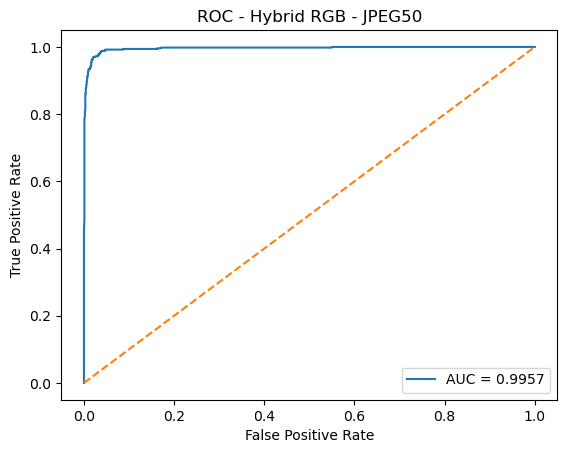

In [2]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ===============================
# CONFIG
# ===============================
MODELS_DIR = r"D:\MinorProject\MinorProject6thSem\models"
TEST_PATH = r"D:\Datasets\test_unseen_JPEG50compressed"

BATCH_SIZE = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ===============================
# TRANSFORM
# ===============================
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ===============================
# DATASET
# ===============================
test_dataset = datasets.ImageFolder(TEST_PATH, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Class mapping:", test_dataset.class_to_idx)

# ===============================
# EVALUATION FUNCTION
# ===============================
def evaluate_model(model, model_name):

    model = model.to(DEVICE)
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            probs = F.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    print(f"\n===== {model_name} - JPEG50 RESULT =====")
    print(f"Test Unseen Loss: {avg_loss:.4f}")
    print(f"Test Unseen Acc:  {accuracy:.4f}")
    print(f"Test Unseen AUC:  {roc_auc:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(all_labels, all_preds))
    print(classification_report(all_labels, all_preds))

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC - {model_name} - JPEG50")
    plt.legend()
    plt.show()


# =====================================================
# 1️⃣ RESNET18 RGB
# =====================================================
resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet.load_state_dict(
    torch.load(
        os.path.join(MODELS_DIR, "best_resnet18_rgb_phase1.pth"),
        map_location=DEVICE,
        weights_only=True
    )
)
evaluate_model(resnet, "ResNet18 RGB")


# =====================================================
# 2️⃣ MOBILENETV2 RGB
# =====================================================
mobilenet = models.mobilenet_v2(weights=None)
mobilenet.classifier[1] = nn.Linear(mobilenet.classifier[1].in_features, 2)
mobilenet.load_state_dict(
    torch.load(
        os.path.join(MODELS_DIR, "best_mobilenetv2_rgb_phase1.pth"),
        map_location=DEVICE,
        weights_only=True
    )
)
evaluate_model(mobilenet, "MobileNetV2 RGB")


# =====================================================
# 3️⃣ EFFICIENTNET-B0 RGB
# =====================================================
efficientnet = models.efficientnet_b0(weights=None)
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features, 2
)
efficientnet.load_state_dict(
    torch.load(
        os.path.join(MODELS_DIR, "best_efficientnetb0_rgb_phase1.pth"),
        map_location=DEVICE,
        weights_only=True
    )
)
evaluate_model(efficientnet, "EfficientNet-B0 RGB")


# =====================================================
# 4️⃣ VIT-B/16 RGB
# =====================================================
vit = models.vit_b_16(weights=None)
vit.heads.head = nn.Linear(vit.heads.head.in_features, 2)
vit.load_state_dict(
    torch.load(
        os.path.join(MODELS_DIR, "best_vitb16_rgb_phase1.pth"),
        map_location=DEVICE,
        weights_only=True
    )
)
evaluate_model(vit, "ViT-B/16 RGB")


# =====================================================
# 5️⃣ DMF-NET RGB
# =====================================================
class DMFNet(nn.Module):
    def __init__(self):
        super(DMFNet, self).__init__()

        self.resnet = models.resnet18(weights=None)
        self.resnet.fc = nn.Identity()

        self.mobilenet = models.mobilenet_v2(weights=None)
        self.mobilenet.classifier = nn.Identity()

        self.proj_res = nn.Linear(512, 256)
        self.proj_mob = nn.Linear(1280, 256)

        self.gate = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

        self.classifier = nn.Linear(256, 2)

    def forward(self, x):
        feat_res = self.resnet(x)
        feat_mob = self.mobilenet(x)

        proj_res = self.proj_res(feat_res)
        proj_mob = self.proj_mob(feat_mob)

        combined = torch.cat([proj_res, proj_mob], dim=1)
        gate_logits = self.gate(combined)
        gate_weights = torch.softmax(gate_logits, dim=1)

        w_res = gate_weights[:, 0].unsqueeze(1)
        w_mob = gate_weights[:, 1].unsqueeze(1)

        fused = w_res * proj_res + w_mob * proj_mob
        output = self.classifier(fused)
        return output


dmf = DMFNet()
dmf.load_state_dict(
    torch.load(
        os.path.join(MODELS_DIR, "best_dmfnet_rgb_phase1.pth"),
        map_location=DEVICE,
        weights_only=True
    )
)
evaluate_model(dmf, "DMFNet RGB")


# =====================================================
# 6️⃣ HYBRID RGB (EffNet + ViT)
# =====================================================
class HybridModel(nn.Module):
    def __init__(self):
        super(HybridModel, self).__init__()

        self.effnet = models.efficientnet_b0(weights=None)
        self.effnet.classifier = nn.Identity()

        self.vit = models.vit_b_16(weights=None)
        self.vit.heads.head = nn.Identity()

        self.proj_eff = nn.Linear(1280, 256)
        self.proj_vit = nn.Linear(768, 256)

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        feat_eff = self.effnet(x)
        feat_vit = self.vit(x)

        proj_eff = self.proj_eff(feat_eff)
        proj_vit = self.proj_vit(feat_vit)

        fused = torch.cat([proj_eff, proj_vit], dim=1)
        output = self.classifier(fused)
        return output


hybrid = HybridModel()
hybrid.load_state_dict(
    torch.load(
        os.path.join(MODELS_DIR, "best_hybrid_rgb_phase1.pth"),
        map_location=DEVICE,
        weights_only=True
    )
)
evaluate_model(hybrid, "Hybrid RGB")